In [4]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [8]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [10]:
def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

def retrieving_fractions(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2018' and int(month) < 10:# don't include jan - apr for 2018
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


# Datasets

## Altimeters

In [11]:
# Read in fraction arrays & find averages
req_yrs = ['2018','2019','2020','2021','2022','2023','2024','2025']

cs2_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/CS2_Corrected/*_Lead_Density.npy'))
cs2_lead_fractions = retrieving_fractions(cs2_lead_folder,req_yrs)

s3_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/S3_Corrected/*_Lead_Density.npy'))
s3_lead_fractions = retrieving_fractions(s3_lead_folder,req_yrs)

is2_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/IS2/*_Lead_Density.npy'))
is2_lead_fractions = retrieving_fractions(is2_lead_folder,req_yrs)


In [12]:
cs2_lead_fractions_flt = np.concatenate([arr.flatten() for arr in cs2_lead_fractions.values()])

is2_lead_fractions_flt = np.concatenate([arr.flatten() for arr in is2_lead_fractions.values()])

s3_lead_fractions_flt = np.concatenate([arr.flatten() for arr in s3_lead_fractions.values()])

In [13]:
cs2_monthly_lead_fractions_fr = pd.read_csv(f'{base_dir}Monthly_Averages/CS2_Arctic_Monthly_Averages_FullRecord.csv')
cs2_monthly_lead_fractions_fr['Datetime'] = pd.to_datetime(cs2_monthly_lead_fractions_fr['Datetime'],
    format='%Y-%m-%d')
is2_monthly_lead_fractions_fr = pd.read_csv(f'{base_dir}Monthly_Averages/IS2_Arctic_Monthly_Averages_FullRecord.csv')
is2_monthly_lead_fractions_fr['Datetime'] = pd.to_datetime(is2_monthly_lead_fractions_fr['Datetime'],
    format='%Y-%m-%d')
s3_monthly_lead_fractions_fr = pd.read_csv(f'{base_dir}Monthly_Averages/S3_Arctic_Monthly_Averages_FullRecord.csv')
s3_monthly_lead_fractions_fr['Datetime'] = pd.to_datetime(s3_monthly_lead_fractions_fr['Datetime'],
    format='%Y-%m-%d')

## LS8

In [14]:
ls8_evaluation_summary = pd.read_excel(f'{base_dir}LS8/LS8_Evaluation.xlsx', dtype={'Idt': str})
ls8_files = ls8_evaluation_summary['LS8 File']
ls8_evaluation_summary['Datetimes'] = pd.to_datetime(ls8_evaluation_summary['Date'].astype(str),format="%Y%m%d")

grid_input_dir = (f'{base_dir}LS8/TenDay_Densities_Cropped/')

array_statistics,mean_statistics = [],[]

for date, str_date,idt in zip(ls8_evaluation_summary['Datetimes'][:],
                          ls8_evaluation_summary['Date'][:],ls8_evaluation_summary['Idt'][:]):
    
    year = str(str_date)[:4]
    ls8_leads = np.load(f'{grid_input_dir}LS8/{str_date}_{idt}_LS8_Lead_Density.npy')
    cs2_leads = np.load(f'{grid_input_dir}CS2/{str_date}_{idt}_CS2_LS8Cropped_Lead_Density.npy')
    s3_leads = np.load(f'{grid_input_dir}S3/{str_date}_{idt}_S3_LS8Cropped_Lead_Density.npy')
    is2_leads = np.load(f'{grid_input_dir}IS2/{str_date}_{idt}_IS2_LS8Cropped_Lead_Density.npy')
    merged_leads = np.load(f'{grid_input_dir}Merged/{str_date}_{idt}_Merged_LS8Cropped_Lead_Density.npy')

    # Means 
    mean_cs2 = np.nanmean(cs2_leads)
    mean_is2 = np.nanmean(is2_leads)
    mean_ls8 = np.nanmean(ls8_leads)
    mean_s3 = np.nanmean(s3_leads)
    mean_merged = np.nanmean(merged_leads)

    mean_statistics.append([str_date,idt,mean_cs2,mean_is2,mean_s3,mean_merged,mean_ls8])


mean_statistics_df = pd.DataFrame(mean_statistics, columns=['Date','Idt',
    'CS2','IS2','S3','Merged','LS8'])

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_46869/2848788879.py:23: RuntimeWarning: Mean of empty slice
  mean_s3 = np.nanmean(s3_leads)


## MODIS

### Comparison to Weekly Merged Dataset

In [15]:
merged_7day_leads = sorted(glob.glob(f'{base_dir}SevenDay_Averages/25km/Merged/*_Merged_Lead_Density.npy'))

weekly_merged_leads = {}
weekly_average_merged_leads = []

for lead_file in merged_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_SevenDay')[0]

    weekly_merged_leads[date_key] = lead_data

    start_date = date_key[0:8]

    avg_lead_data = np.nanmean(lead_data)
    weekly_average_merged_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_merged_leads_df = pd.DataFrame(weekly_average_merged_leads)
weekly_average_merged_leads_df['Datetime'] = pd.to_datetime(weekly_average_merged_leads_df['StartDate'],
    format='%Y%m%d')

# Comparison to MODIS Dataset
modis_7day_leads = sorted(glob.glob(f'{base_dir}MODIS_LeadFraction/Weekly_Averages_25km_Grid/*_MODIS_Weekly_Average_LFA.npy'))

weekly_modis_leads = {}
weekly_average_modis_leads = []

for lead_file in modis_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_MODIS')[0]

    weekly_modis_leads[date_key] = lead_data

    start_date = date_key[0:8]
    
    avg_lead_data = np.nanmean(lead_data)
    weekly_average_modis_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_modis_leads_df = pd.DataFrame(weekly_average_modis_leads)
weekly_average_modis_leads_df['Datetime'] = pd.to_datetime(weekly_average_modis_leads_df['StartDate'],
    format='%Y%m%d')

# Remove datekeys in merged dataset not present in MODIS
common_keys = weekly_merged_leads.keys() & weekly_modis_leads.keys()

weekly_merged_leads_filt = dict1 = {k: v for k, v in weekly_merged_leads.items() if k in weekly_modis_leads}

# Flatten for histograms
weekly_merged_leads_flt = np.concatenate([arr.flatten() for arr in weekly_merged_leads_filt.values()])
weekly_modis_leads_flt = np.concatenate([arr.flatten() for arr in weekly_modis_leads.values()])

# Merge dataframes on their date for scatter plot
leads_LFA_both_ds = weekly_average_modis_leads_df.merge(weekly_average_merged_leads_df, 
                                                        on='Datetime', how='inner', suffixes=(' MODIS', ' Merged'))
leads_LFA_both_ds_df = leads_LFA_both_ds.drop(['Date MODIS','StartDate MODIS','Date Merged','StartDate Merged'],axis=1)

### Comparison to Weekly CS2/S3 Merged Dataset

In [16]:
s3_cs2_merged_7day_leads = sorted(glob.glob(f'{base_dir}SevenDay_Averages/25km/S3_CS2_Merged/*_Merged_Lead_Density.npy'))

weekly_s3_cs2_merged_leads = {}
weekly_average_s3_cs2_merged_leads = []

for lead_file in s3_cs2_merged_7day_leads[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_SevenDay')[0]

    weekly_s3_cs2_merged_leads[date_key] = lead_data

    start_date = date_key[0:8]

    avg_lead_data = np.nanmean(lead_data)
    weekly_average_s3_cs2_merged_leads.append({'Date':date_key,'Lead Density (%)':avg_lead_data,
                                       'StartDate':start_date})
    
weekly_average_s3_cs2_merged_leads_df = pd.DataFrame(weekly_average_s3_cs2_merged_leads)
weekly_average_s3_cs2_merged_leads_df['Datetime'] = pd.to_datetime(weekly_average_s3_cs2_merged_leads_df['StartDate'],
    format='%Y%m%d')

# Remove datekeys in merged dataset not present in MODIS
common_keys = weekly_s3_cs2_merged_leads.keys() & weekly_modis_leads.keys()

weekly_s3_cs2_merged_leads_filt = dict1 = {k: v for k, v in weekly_s3_cs2_merged_leads.items() if k in weekly_modis_leads}

# Flatten for histograms
weekly_s3_cs2_merged_leads_flt = np.concatenate([arr.flatten() for arr in weekly_s3_cs2_merged_leads_filt.values()])
weekly_modis_leads_flt = np.concatenate([arr.flatten() for arr in weekly_modis_leads.values()])

# Merge dataframes on their date for scatter plot
leads_LFA_both_s3_cs2_ds = weekly_average_modis_leads_df.merge(weekly_average_s3_cs2_merged_leads_df, 
                                                        on='Datetime', how='inner', suffixes=(' MODIS', ' Merged'))
leads_LFA_both_s3_cs2_ds_df = leads_LFA_both_s3_cs2_ds.drop(['Date MODIS','StartDate MODIS','Date Merged','StartDate Merged'],axis=1)

### Comparison to Monthly Merged Dataset

In [17]:
merged_monthly_leads = pd.read_csv(f'{base_dir}Monthly_Averages/Merged_Lead_Fraction_Averages.csv')
merged_monthly_leads['Datetime'] = pd.to_datetime(merged_monthly_leads['Month'],
    format='%Y%m')

modis_monthly_avg_leads = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_Monthly_Average_LFA_AllYears.csv')
modis_monthly_avg_leads['Datetime'] = pd.to_datetime(modis_monthly_avg_leads['Datetime'],
    format='%Y-%m-%d')
modis_monthly_avg_leads_mg = modis_monthly_avg_leads.rename(columns={c:c+'_MODIS' for c in modis_monthly_avg_leads.columns if c not in ['Datetime']})

modis_merged_monthly_leads = merged_monthly_leads.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' Merged', ' MODIS'))
modis_merged_monthly_leads = modis_merged_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Month'],axis=1)
modis_merged_monthly_leads = modis_merged_monthly_leads.rename(columns={'Lead Density (%)_MODIS':'MODIS Lead Density'})

In [18]:
# Read in fraction arrays & find averages
req_yrs = ['2018','2019','2020','2021','2022']
merged_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/Merged/*_Lead_Density.npy'))
merged_lead_fractions_modis = retrieving_fractions(merged_lead_folder,req_yrs)

monthly_modis_leads_files = sorted(glob.glob(f'{base_dir}MODIS_LeadFraction/Monthly_Averages_25km_Grid/*_MODIS_Monthly_Average_LFA.npy'))

monthly_modis_leads = {}

for lead_file in monthly_modis_leads_files[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_')[0]
    date_key = date_key[0:6]
    
    monthly_modis_leads[date_key] = lead_data

common_keys = (merged_lead_fractions_modis.keys()
    & monthly_modis_leads.keys())

# Remove datekeys in altimeter datasets not present in MODIS
merged_lead_fractions_modis_filt = {k: v for k, v in merged_lead_fractions_modis.items() if k in common_keys}

merged_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in merged_lead_fractions_modis_filt.values()])


### Comparison to Monthly CS2/S3 Dataset

In [20]:
s3_cs2_merged_monthly_leads = pd.read_csv(f'{base_dir}Monthly_Averages/S3_CS2_Merged_Lead_Fraction_Averages.csv')
s3_cs2_merged_monthly_leads['Datetime'] = pd.to_datetime(s3_cs2_merged_monthly_leads['Month'],
    format='%Y%m')

modis_monthly_avg_leads = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_Monthly_Average_LFA_AllYears.csv')
modis_monthly_avg_leads['Datetime'] = pd.to_datetime(modis_monthly_avg_leads['Datetime'],
    format='%Y-%m-%d')
modis_monthly_avg_leads_mg = modis_monthly_avg_leads.rename(columns={c:c+'_MODIS' for c in modis_monthly_avg_leads.columns if c not in ['Datetime']})

modis_s3_cs2_merged_monthly_leads = s3_cs2_merged_monthly_leads.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' S3 CS2 Merged', ' MODIS'))
modis_s3_cs2_merged_monthly_leads = modis_s3_cs2_merged_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Month'],axis=1)
modis_s3_cs2_merged_monthly_leads = modis_s3_cs2_merged_monthly_leads.rename(columns={'Lead Density (%)_MODIS':'MODIS Lead Density'})

In [21]:
# Read in fraction arrays & find averages
req_yrs = ['2018','2019','2020','2021','2022']
s3_cs2_merged_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/S3_CS2_Merged/*_Lead_Density.npy'))
s3_cs2_merged_lead_fractions_modis = retrieving_fractions(s3_cs2_merged_lead_folder,req_yrs)

monthly_modis_leads_files = sorted(glob.glob(f'{base_dir}MODIS_LeadFraction/Monthly_Averages_25km_Grid/*_MODIS_Monthly_Average_LFA.npy'))

monthly_modis_leads = {}

for lead_file in monthly_modis_leads_files[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_')[0]
    date_key = date_key[0:6]
    
    monthly_modis_leads[date_key] = lead_data

common_keys = (s3_cs2_merged_lead_fractions_modis.keys()
    & monthly_modis_leads.keys())

# Remove datekeys in altimeter datasets not present in MODIS
s3_cs2_merged_lead_fractions_modis_filt = {k: v for k, v in s3_cs2_merged_lead_fractions_modis.items() if k in common_keys}

s3_cs2_merged_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in s3_cs2_merged_lead_fractions_modis_filt.values()])


### Comparison to Individual Altimeter Datasets

In [22]:
modis_monthly_avg_leads = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_Monthly_Average_LFA_AllYears.csv')
modis_monthly_avg_leads['Datetime'] = pd.to_datetime(modis_monthly_avg_leads['Datetime'],
    format='%Y-%m-%d')

modis_monthly_avg_leads_mg = modis_monthly_avg_leads.rename(columns={c:c+'_MODIS' for c in modis_monthly_avg_leads.columns if c not in ['Datetime']})

modis_is2_monthly_leads = is2_monthly_lead_fractions_fr.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' IS2', ' MODIS'))
modis_is2_monthly_leads = modis_is2_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Date'],axis=1)
modis_is2_monthly_leads = modis_is2_monthly_leads.rename(columns={'Lead Density': 'IS2 Lead Density','Lead Density (%)_MODIS':'MODIS Lead Density'})

modis_cs2_monthly_leads = cs2_monthly_lead_fractions_fr.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' CS2', ' MODIS'))
modis_cs2_monthly_leads = modis_cs2_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Date'],axis=1)
modis_cs2_monthly_leads = modis_cs2_monthly_leads.rename(columns={'Lead Density': 'CS2 Lead Density','Lead Density (%)_MODIS':'MODIS Lead Density'})

modis_s3_monthly_leads = s3_monthly_lead_fractions_fr.merge(modis_monthly_avg_leads_mg, 
                                                              on='Datetime', how='inner', suffixes=(' S3', ' MODIS'))
modis_s3_monthly_leads = modis_s3_monthly_leads.drop(['StartDate_MODIS','EndDate_MODIS','Date_MODIS','Date'],axis=1)
modis_s3_monthly_leads = modis_s3_monthly_leads.rename(columns={'Lead Density': 'S3 Lead Density','Lead Density (%)_MODIS':'MODIS Lead Density'})

In [23]:
# Read in fraction arrays & find averages
req_yrs = ['2018','2019','2020','2021','2022']

cs2_lead_fractions_modis = retrieving_fractions(cs2_lead_folder,req_yrs)

s3_lead_fractions_modis = retrieving_fractions(s3_lead_folder,req_yrs)

is2_lead_fractions_modis = retrieving_fractions(is2_lead_folder,req_yrs)


In [24]:
monthly_modis_leads_files = sorted(glob.glob(f'{base_dir}MODIS_LeadFraction/Monthly_Averages_25km_Grid/*_MODIS_Monthly_Average_LFA.npy'))

monthly_modis_leads = {}

for lead_file in monthly_modis_leads_files[:]:
    lead_data0 = np.load(lead_file)
    lead_data = np.where(land_mask_buffered, np.nan, lead_data0)
    
    filename = os.path.basename(lead_file)
    date_key = filename.split('_')[0]
    date_key = date_key[0:6]
    
    monthly_modis_leads[date_key] = lead_data

common_keys = (cs2_lead_fractions_modis.keys()
    & is2_lead_fractions_modis.keys()
    & s3_lead_fractions_modis.keys()
    & monthly_modis_leads.keys())

# Remove datekeys in altimeter datasets not present in MODIS
cs2_lead_fractions_modis_filt = {k: v for k, v in cs2_lead_fractions_modis.items() if k in common_keys}

is2_lead_fractions_modis_filt = {k: v for k, v in is2_lead_fractions_modis.items() if k in common_keys}

s3_lead_fractions_modis_filt = {k: v for k, v in s3_lead_fractions_modis.items() if k in common_keys}

monthly_modis_leads_filt = {k: v for k, v in monthly_modis_leads.items() if k in common_keys}

cs2_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in cs2_lead_fractions_modis_filt.values()])
is2_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in is2_lead_fractions_modis_filt.values()])
s3_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in s3_lead_fractions_modis_filt.values()])
modis_lead_fractions_modis_flt = np.concatenate([arr.flatten() for arr in monthly_modis_leads_filt.values()])

# Figures

## Including Merged

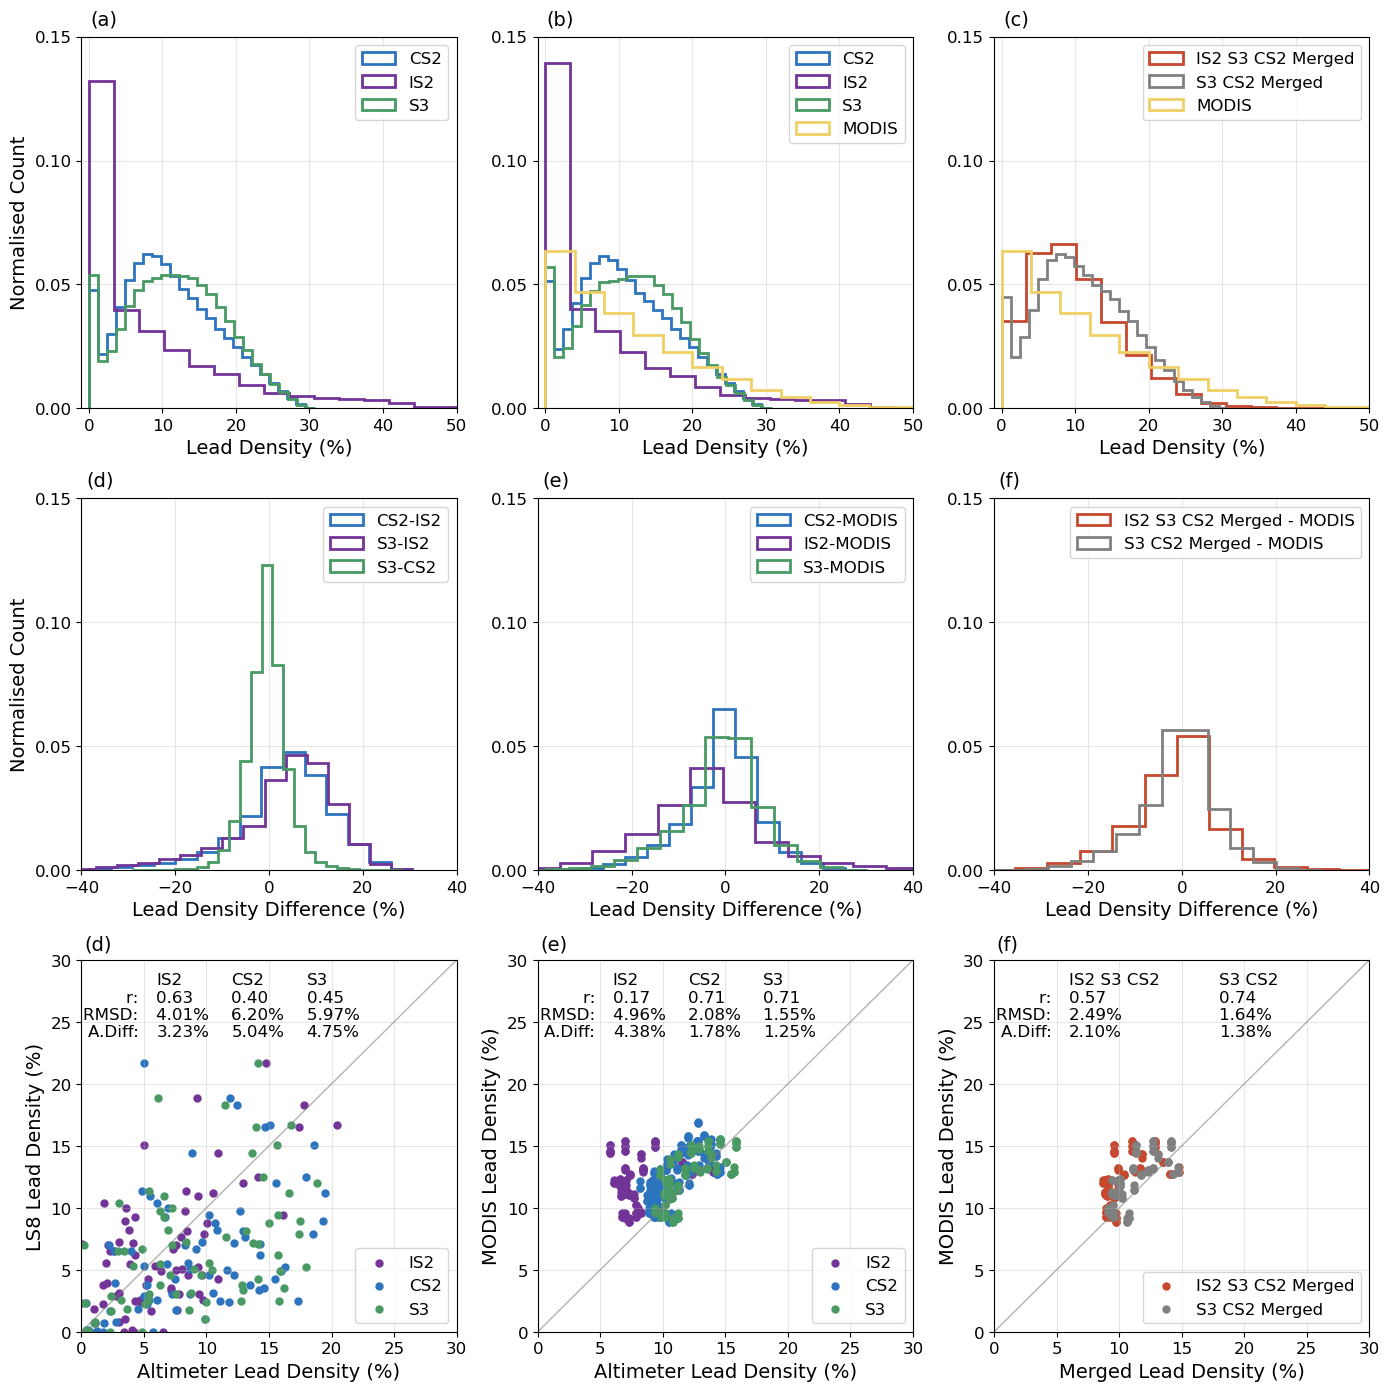

In [89]:
cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'
modis_lead_colour = '#F0CF65'
s3_cs2_merged_lead_colour = 'grey'

fig, ax = plt.subplots(3,3,figsize=(14, 14))

# --- HISTOGRAMS --- #
# Individual Altimeters #
h_cs2_lead = ax[0,0].hist(cs2_lead_fractions_flt, histtype='step', density=True,
                     bins=25, edgecolor=cs2_lead_colour, linewidth=2, label='CS2 Leads')

h_is2_lead = ax[0,0].hist(is2_lead_fractions_flt, histtype='step', density=True,
                     bins=25, edgecolor=is2_lead_colour, linewidth=2, label='IS2 Leads')

h_s3_lead = ax[0,0].hist(s3_lead_fractions_flt, histtype='step', density=True,
                    bins=25, edgecolor=s3_lead_colour, linewidth=2, label='S3 Leads')

h_cs2_is2_lead = ax[1,0].hist((cs2_lead_fractions_flt - is2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=cs2_lead_colour, linewidth=2, label='CS2 - IS2')

h_s3_is2_lead = ax[1,0].hist((s3_lead_fractions_flt - is2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=is2_lead_colour, linewidth=2, label='S3 - IS2')

h_s3_cs2_lead = ax[1,0].hist((s3_lead_fractions_flt - cs2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=s3_lead_colour, linewidth=2, label='S3 - CS2')

# Individual Altimeters and MODIS #
h_cs2_m_lead = ax[0,1].hist(cs2_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=cs2_lead_colour, linewidth=2, label='CS2 Leads')

h_is2_m_lead = ax[0,1].hist(is2_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=is2_lead_colour, linewidth=2, label='IS2 Leads')

h_s3_m_lead = ax[0,1].hist(s3_lead_fractions_modis_flt, histtype='step', density=True,
                    bins=25, edgecolor=s3_lead_colour, linewidth=2, label='S3 Leads')

h_modis_lead = ax[0,1].hist(modis_lead_fractions_modis_flt, histtype='step', density=True,
                    bins=25, edgecolor=modis_lead_colour, linewidth=2, label='MODIS Leads')

h_cs2_modis_lead = ax[1,1].hist((cs2_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=cs2_lead_colour, linewidth=2, label='CS2 - MODIS')

h_is2_modis_lead = ax[1,1].hist((is2_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=is2_lead_colour, linewidth=2, label='IS2 - MODIS')

h_s3_modis_lead = ax[1,1].hist((s3_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=s3_lead_colour, linewidth=2, label='S3 - MODIS')


# Merged and MODIS #
h_merged_lead = ax[0,2].hist(merged_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=merged_lead_colour, linewidth=2, label='IS2 S3 CS2 Merged')
h_s3_cs2_merged_lead = ax[0,2].hist(s3_cs2_merged_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=s3_cs2_merged_lead_colour, linewidth=2, label='S3 CS2 Merged')
h_modis_lead = ax[0,2].hist(modis_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=modis_lead_colour, linewidth=2, label='MODIS')

h_merged_modis_lead = ax[1,2].hist((merged_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=merged_lead_colour, linewidth=2, label='IS2 S3 CS2 Merged - MODIS')
h_s3_cs2_merged_modis_lead = ax[1,2].hist((s3_cs2_merged_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=s3_cs2_merged_lead_colour, linewidth=2, label='S3 CS2 Merged - MODIS')


# --- SCATTERS --- #
# Individual Altimeters
ax[2,0].scatter(mean_statistics_df['IS2'],
            mean_statistics_df['LS8'],
            color=is2_lead_colour, marker='o', s=25,label='IS2')
ax[2,0].scatter(mean_statistics_df['CS2'],
            mean_statistics_df['LS8'],
            color=cs2_lead_colour, marker='o', s=25,label='CS2')
ax[2,0].scatter(mean_statistics_df['S3'],
            mean_statistics_df['LS8'],
            color=s3_lead_colour, marker='o', s=25,label='S3')

# Individual Altimeters and MODIS #
ax[2,1].scatter(modis_is2_monthly_leads['IS2 Lead Density'],
            modis_is2_monthly_leads['MODIS Lead Density'],
            color=is2_lead_colour, marker='o', s=25,label='IS2')
ax[2,1].scatter(modis_cs2_monthly_leads['CS2 Lead Density'],
            modis_cs2_monthly_leads['MODIS Lead Density'],
            color=cs2_lead_colour, marker='o', s=25,label='CS2')
ax[2,1].scatter(modis_s3_monthly_leads['S3 Lead Density'],
            modis_s3_monthly_leads['MODIS Lead Density'],
            color=s3_lead_colour, marker='o', s=25,label='S3')

# Merged and MODIS
ax[2,2].scatter(modis_merged_monthly_leads['Merged'],
            modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],
            color=merged_lead_colour, marker='o', s=25,label='IS2 S3 CS2 Merged')
ax[2,2].scatter(modis_s3_cs2_merged_monthly_leads['Merged'],
            modis_s3_cs2_merged_monthly_leads['MODIS Lead Density'],
            color=s3_cs2_merged_lead_colour, marker='o', s=25,label='S3 CS2 Merged')
#ax2.set_box_aspect(1)

# --- FORMATTING ---
for a in ax[0, :3].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_ylim([0, 0.15])
    a.set_xlim([-1, 50])
    a.yaxis.set_major_locator(MultipleLocator(0.05))

for a in ax[1, :3].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_ylim([0, 0.15])
    a.set_xlim([-40, 40])
    a.yaxis.set_major_locator(MultipleLocator(0.05))


for a in ax[2, :3].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_xlim([0,30])
    a.set_ylim([0,30])
    a.yaxis.set_major_locator(MultipleLocator(5))
    a.xaxis.set_major_locator(MultipleLocator(5))
    a.axline((0, 0), (30, 30), linestyle='-', color='grey', alpha=0.6,linewidth=1)

# Axis Labels
ax[0,0].set_ylabel('Normalised Count', fontsize=14)
ax[1,0].set_ylabel('Normalised Count', fontsize=14)

ax[0,0].set_xlabel('Lead Density (%)', fontsize=14)
ax[0,1].set_xlabel('Lead Density (%)', fontsize=14)
ax[0,2].set_xlabel('Lead Density (%)', fontsize=14)

ax[1,0].set_xlabel('Lead Density Difference (%)', fontsize=14)
ax[1,1].set_xlabel('Lead Density Difference (%)', fontsize=14)
ax[1,2].set_xlabel('Lead Density Difference (%)', fontsize=14)

ax[2,0].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[2,0].set_ylabel('LS8 Lead Density (%)',fontsize=14)

ax[2,1].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[2,1].set_ylabel('MODIS Lead Density (%)',fontsize=14)

ax[2,2].set_xlabel('Merged Lead Density (%)',fontsize=14)
ax[2,2].set_ylabel('MODIS Lead Density (%)',fontsize=14)

# Legends
# Left Column
lead_handles = [h_cs2_lead[2][0], h_is2_lead[2][0], h_s3_lead[2][0]]
diff_handles = [h_cs2_is2_lead[2][0], h_s3_is2_lead[2][0], h_s3_cs2_lead[2][0]]

ax[0,0].legend(handles=lead_handles, labels=['CS2', 'IS2', 'S3'],
           loc='upper right', fontsize=12, frameon=True)

ax[1,0].legend(handles=diff_handles, labels=['CS2-IS2', 'S3-IS2', 'S3-CS2'],
           loc='upper right', fontsize=12, frameon=True)

ax[2,0].legend(loc='lower right', fontsize=12, frameon=True)

# Middle Column
lead_handles = [h_cs2_m_lead[2][0], h_is2_m_lead[2][0], h_s3_m_lead[2][0],h_modis_lead[2][0]]
diff_handles = [h_cs2_modis_lead[2][0], h_is2_modis_lead[2][0], h_s3_modis_lead[2][0]]

ax[0,1].legend(handles=lead_handles, labels=['CS2', 'IS2', 'S3','MODIS'],
           loc='upper right', fontsize=12, frameon=True)

ax[1,1].legend(handles=diff_handles, labels=['CS2-MODIS', 'IS2-MODIS', 'S3-MODIS'],
           loc='upper right', fontsize=12, frameon=True)
ax[2,1].legend(loc='lower right', fontsize=12, frameon=True)

# Right Column
ax[0,2].legend(loc='upper right', fontsize=12, frameon=True)
ax[1,2].legend(loc='upper right', fontsize=12, frameon=True)
ax[2,2].legend(loc='lower right', fontsize=12, frameon=True)

# Statistics

# Left Column
ax[2,0].text(5,29,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')

ax[2,0].text(6,29,f"IS2\n"
           f"{corr(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,0].text(12,29,f"CS2\n"
           f"{corr(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ls8_s3 = mean_statistics_df.copy()
ls8_s3 = ls8_s3.dropna()
ax[2,0].text(18,29,f"S3\n"
           f"{corr(ls8_s3['S3'],ls8_s3['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['S3'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['S3'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

# Centre Column
ax[2,1].text(5,29,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')

ax[2,1].text(6,29,f"IS2\n"
           f"{corr(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,1].text(12,29,f"CS2\n"
           f"{corr(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,1].text(18,29,f"S3\n"
           f"{corr(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

            

# Right Column
ax[2,2].text(5,29,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')
ax[2,2].text(6,29,f"IS2 S3 CS2\n"
           f"{corr(modis_merged_monthly_leads['Merged'],modis_merged_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_merged_monthly_leads['Merged'],modis_merged_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_merged_monthly_leads['Merged'],modis_merged_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')
ax[2,2].text(18,29,f"S3 CS2\n"
           f"{corr(modis_s3_cs2_merged_monthly_leads['Merged'],modis_s3_cs2_merged_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_s3_cs2_merged_monthly_leads['Merged'],modis_s3_cs2_merged_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_s3_cs2_merged_monthly_leads['Merged'],modis_s3_cs2_merged_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

# Subplot labels
ax[0,0].text(0.2,0.155,'(a)',fontsize=14)
ax[0,1].text(0.2,0.155,'(b)',fontsize=14)
ax[0,2].text(0.2,0.155,'(c)',fontsize=14)

ax[1,0].text(-39,0.155,'(d)',fontsize=14)
ax[1,1].text(-39,0.155,'(e)',fontsize=14)
ax[1,2].text(-39,0.155,'(f)',fontsize=14)

ax[2,0].text(0.2,30.8,'(d)',fontsize=14)
ax[2,1].text(0.2,30.8,'(e)',fontsize=14)
ax[2,2].text(0.2,30.8,'(f)',fontsize=14)


plt.tight_layout()
plt.show()

#fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig3.png',dpi=300,bbox_inches="tight")

## Not Including Merged

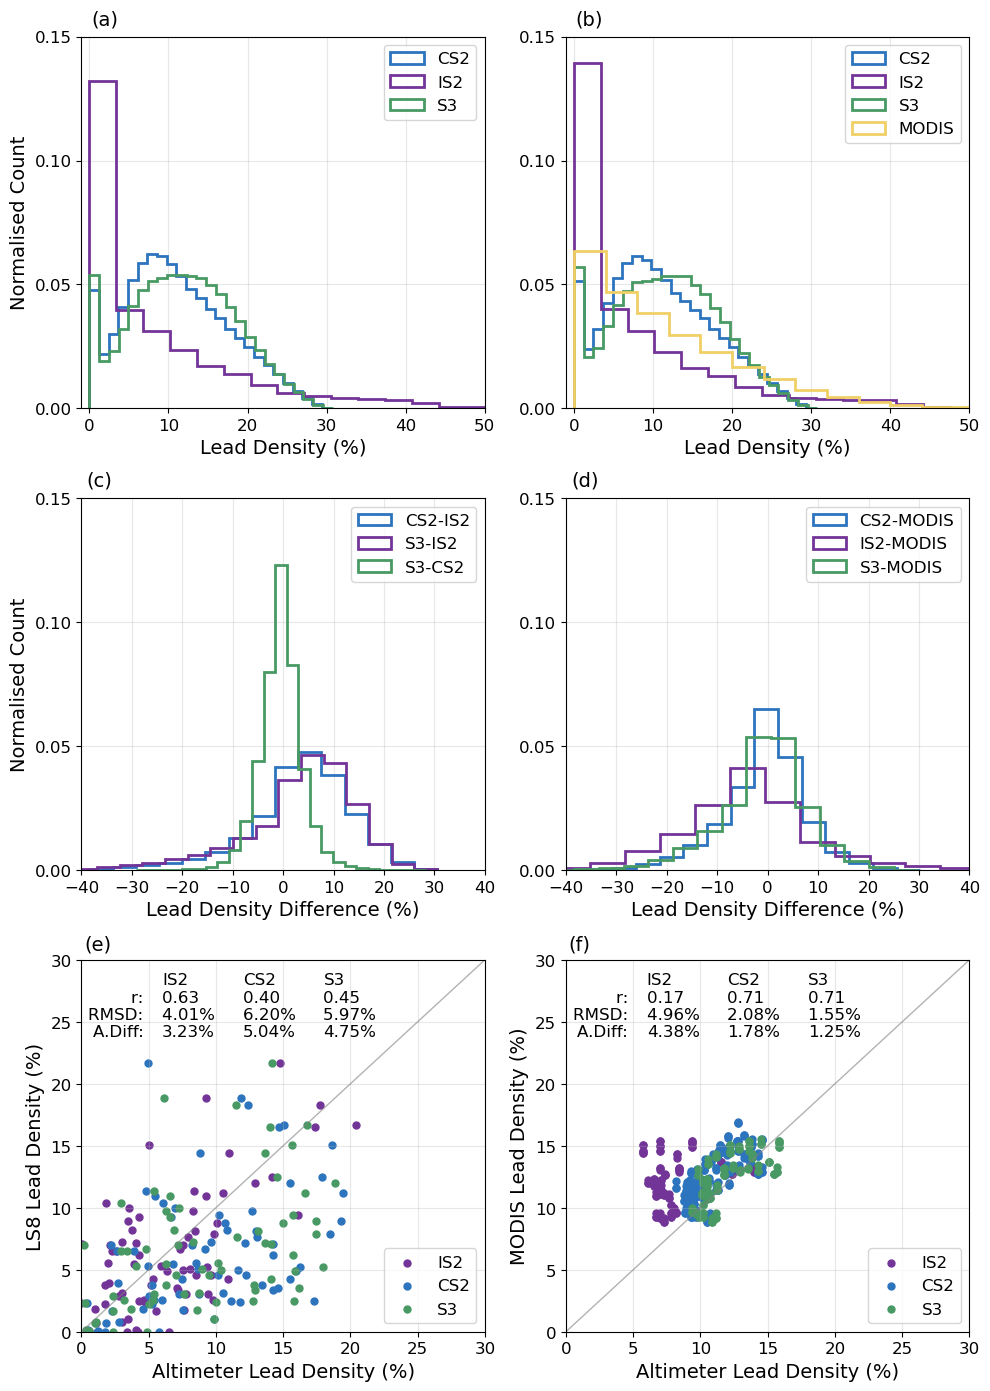

In [91]:
cs2_lead_colour = '#2D74BE'
s3_lead_colour = '#489963'
is2_lead_colour = '#733498'
merged_lead_colour = '#C6482F'
modis_lead_colour = '#F0CF65'
s3_cs2_merged_lead_colour = 'grey'

fig, ax = plt.subplots(3,2,figsize=(10, 14))

# --- HISTOGRAMS --- #
# Individual Altimeters #
h_cs2_lead = ax[0,0].hist(cs2_lead_fractions_flt, histtype='step', density=True,
                     bins=25, edgecolor=cs2_lead_colour, linewidth=2, label='CS2 Leads')

h_is2_lead = ax[0,0].hist(is2_lead_fractions_flt, histtype='step', density=True,
                     bins=25, edgecolor=is2_lead_colour, linewidth=2, label='IS2 Leads')

h_s3_lead = ax[0,0].hist(s3_lead_fractions_flt, histtype='step', density=True,
                    bins=25, edgecolor=s3_lead_colour, linewidth=2, label='S3 Leads')

h_cs2_is2_lead = ax[1,0].hist((cs2_lead_fractions_flt - is2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=cs2_lead_colour, linewidth=2, label='CS2 - IS2')

h_s3_is2_lead = ax[1,0].hist((s3_lead_fractions_flt - is2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=is2_lead_colour, linewidth=2, label='S3 - IS2')

h_s3_cs2_lead = ax[1,0].hist((s3_lead_fractions_flt - cs2_lead_fractions_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=s3_lead_colour, linewidth=2, label='S3 - CS2')

# Individual Altimeters and MODIS #
h_cs2_m_lead = ax[0,1].hist(cs2_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=cs2_lead_colour, linewidth=2, label='CS2 Leads')

h_is2_m_lead = ax[0,1].hist(is2_lead_fractions_modis_flt, histtype='step', density=True,
                     bins=25, edgecolor=is2_lead_colour, linewidth=2, label='IS2 Leads')

h_s3_m_lead = ax[0,1].hist(s3_lead_fractions_modis_flt, histtype='step', density=True,
                    bins=25, edgecolor=s3_lead_colour, linewidth=2, label='S3 Leads')

h_modis_lead = ax[0,1].hist(modis_lead_fractions_modis_flt, histtype='step', density=True,
                    bins=25, edgecolor=modis_lead_colour, linewidth=2, label='MODIS Leads')

h_cs2_modis_lead = ax[1,1].hist((cs2_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=cs2_lead_colour, linewidth=2, label='CS2 - MODIS')

h_is2_modis_lead = ax[1,1].hist((is2_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=is2_lead_colour, linewidth=2, label='IS2 - MODIS')

h_s3_modis_lead = ax[1,1].hist((s3_lead_fractions_modis_flt - modis_lead_fractions_modis_flt),
                         histtype='step', density=True, bins=25,
                         edgecolor=s3_lead_colour, linewidth=2, label='S3 - MODIS')


# --- SCATTERS --- #
# Individual Altimeters
ax[2,0].scatter(mean_statistics_df['IS2'],
            mean_statistics_df['LS8'],
            color=is2_lead_colour, marker='o', s=25,label='IS2')
ax[2,0].scatter(mean_statistics_df['CS2'],
            mean_statistics_df['LS8'],
            color=cs2_lead_colour, marker='o', s=25,label='CS2')
ax[2,0].scatter(mean_statistics_df['S3'],
            mean_statistics_df['LS8'],
            color=s3_lead_colour, marker='o', s=25,label='S3')

# Individual Altimeters and MODIS #
ax[2,1].scatter(modis_is2_monthly_leads['IS2 Lead Density'],
            modis_is2_monthly_leads['MODIS Lead Density'],
            color=is2_lead_colour, marker='o', s=25,label='IS2')
ax[2,1].scatter(modis_cs2_monthly_leads['CS2 Lead Density'],
            modis_cs2_monthly_leads['MODIS Lead Density'],
            color=cs2_lead_colour, marker='o', s=25,label='CS2')
ax[2,1].scatter(modis_s3_monthly_leads['S3 Lead Density'],
            modis_s3_monthly_leads['MODIS Lead Density'],
            color=s3_lead_colour, marker='o', s=25,label='S3')


# --- FORMATTING ---
for a in ax[0, :2].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_ylim([0, 0.15])
    a.set_xlim([-1, 50])
    a.yaxis.set_major_locator(MultipleLocator(0.05))

for a in ax[1, :2].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_ylim([0, 0.15])
    a.set_xlim([-40, 40])
    a.yaxis.set_major_locator(MultipleLocator(0.05))


for a in ax[2, :2].flatten():
    a.xaxis.grid(True, 'major', alpha=0.3)
    a.yaxis.grid(True, 'major', alpha=0.3)
    a.tick_params(axis='both', labelsize=12)
    a.set_xlim([0,30])
    a.set_ylim([0,30])
    a.yaxis.set_major_locator(MultipleLocator(5))
    a.xaxis.set_major_locator(MultipleLocator(5))
    a.axline((0, 0), (30, 30), linestyle='-', color='grey', alpha=0.6,linewidth=1)

# Axis Labels
ax[0,0].set_ylabel('Normalised Count', fontsize=14)
ax[1,0].set_ylabel('Normalised Count', fontsize=14)

ax[0,0].set_xlabel('Lead Density (%)', fontsize=14)
ax[0,1].set_xlabel('Lead Density (%)', fontsize=14)

ax[1,0].set_xlabel('Lead Density Difference (%)', fontsize=14)
ax[1,1].set_xlabel('Lead Density Difference (%)', fontsize=14)

ax[2,0].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[2,0].set_ylabel('LS8 Lead Density (%)',fontsize=14)

ax[2,1].set_xlabel('Altimeter Lead Density (%)',fontsize=14)
ax[2,1].set_ylabel('MODIS Lead Density (%)',fontsize=14)


# Legends
# Left Column
lead_handles = [h_cs2_lead[2][0], h_is2_lead[2][0], h_s3_lead[2][0]]
diff_handles = [h_cs2_is2_lead[2][0], h_s3_is2_lead[2][0], h_s3_cs2_lead[2][0]]

ax[0,0].legend(handles=lead_handles, labels=['CS2', 'IS2', 'S3'],
           loc='upper right', fontsize=12, frameon=True)

ax[1,0].legend(handles=diff_handles, labels=['CS2-IS2', 'S3-IS2', 'S3-CS2'],
           loc='upper right', fontsize=12, frameon=True)

ax[2,0].legend(loc='lower right', fontsize=12, frameon=True)

# Middle Column
lead_handles = [h_cs2_m_lead[2][0], h_is2_m_lead[2][0], h_s3_m_lead[2][0],h_modis_lead[2][0]]
diff_handles = [h_cs2_modis_lead[2][0], h_is2_modis_lead[2][0], h_s3_modis_lead[2][0]]

ax[0,1].legend(handles=lead_handles, labels=['CS2', 'IS2', 'S3','MODIS'],
           loc='upper right', fontsize=12, frameon=True)

ax[1,1].legend(handles=diff_handles, labels=['CS2-MODIS', 'IS2-MODIS', 'S3-MODIS'],
           loc='upper right', fontsize=12, frameon=True)
ax[2,1].legend(loc='lower right', fontsize=12, frameon=True)


# Statistics

# Left Column
ax[2,0].text(5,29,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')

ax[2,0].text(6,29,f"IS2\n"
           f"{corr(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['IS2'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,0].text(12,29,f"CS2\n"
           f"{corr(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['CS2'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ls8_s3 = mean_statistics_df.copy()
ls8_s3 = ls8_s3.dropna()
ax[2,0].text(18,29,f"S3\n"
           f"{corr(ls8_s3['S3'],ls8_s3['LS8']):.2f} \n"
           f"{rmsd(mean_statistics_df['S3'],mean_statistics_df['LS8']):.2f}% \n"
           f"{absdiff(mean_statistics_df['S3'],mean_statistics_df['LS8']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

# Centre Column
ax[2,1].text(5,29,f"\nr: \nRMSD: \nA.Diff: \n",
           fontsize=12,verticalalignment='top',horizontalalignment='right')

ax[2,1].text(6,29,f"IS2\n"
           f"{corr(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_is2_monthly_leads['IS2 Lead Density'],modis_is2_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,1].text(12,29,f"CS2\n"
           f"{corr(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_cs2_monthly_leads['CS2 Lead Density'],modis_cs2_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax[2,1].text(18,29,f"S3\n"
           f"{corr(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f} \n"
           f"{rmsd(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f}% \n"
           f"{absdiff(modis_s3_monthly_leads['S3 Lead Density'],modis_s3_monthly_leads['MODIS Lead Density']):.2f}%",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

            
# Subplot labels
ax[0,0].text(0.2,0.155,'(a)',fontsize=14)
ax[0,1].text(0.2,0.155,'(b)',fontsize=14)

ax[1,0].text(-39,0.155,'(c)',fontsize=14)
ax[1,1].text(-39,0.155,'(d)',fontsize=14)

ax[2,0].text(0.2,30.8,'(e)',fontsize=14)
ax[2,1].text(0.2,30.8,'(f)',fontsize=14)


plt.tight_layout()
plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/Fig3.png',dpi=300,bbox_inches="tight")

## MODIS and LS8

In [56]:
modis_ls8_stats = pd.read_csv(f'{base_dir}MODIS_LeadFraction/MODIS_LS8_Mean_Statistics.csv',index_col=0)
ls8_mean_stats = mean_statistics_df.copy()

ls8_mean_stats['Datetime'] = pd.to_datetime(ls8_mean_stats['Date'],format="%Y%m%d")
modis_ls8_stats['Datetime'] = pd.to_datetime(modis_ls8_stats['Date Str'],format="%Y%m%d")

modis_ls8_stats['LS8 Idt'] = modis_ls8_stats['LS8 Idt'].astype(str).str.zfill(6)

modis_ls8_df = (ls8_mean_stats[['Datetime', 'Idt', 'LS8']]
    .merge(modis_ls8_stats[['Datetime', 'LS8 Idt', 'MODIS Mean']],
        left_on=['Datetime', 'Idt'],
        right_on=['Datetime', 'LS8 Idt'],
        how='inner')
    .rename(columns={'Idt': 'LS8 Idt'})
    [['Datetime', 'LS8 Idt', 'LS8', 'MODIS Mean']])


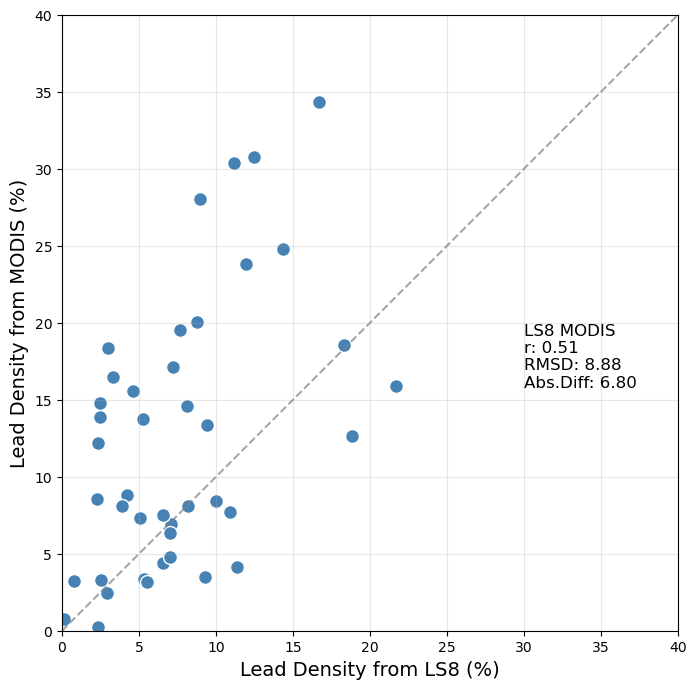

In [64]:
fig, ax = plt.subplots(figsize=[8, 8])
ax.scatter(modis_ls8_df['LS8'],modis_ls8_df['MODIS Mean'],color='steelblue',
            edgecolor='white', s=100, alpha=1)
ax.plot(np.arange(0, 50), linestyle='--', alpha=0.7, color='grey') 
ax.set_ylim(0,40)
ax.set_xlim(0,40)
ax.set_aspect('equal')
ax.xaxis.grid(True, 'major', alpha=0.3)
ax.yaxis.grid(True, 'major', alpha=0.3)

ax.text(30,20,f"LS8 MODIS \n"
           f"r: {corr(modis_ls8_df['LS8'],modis_ls8_df['MODIS Mean']):.2f} \n"
           f"RMSD: {rmsd(modis_ls8_df['LS8'],modis_ls8_df['MODIS Mean']):.2f} \n"
           f"Abs.Diff: {absdiff(modis_ls8_df['LS8'],modis_ls8_df['MODIS Mean']):.2f}",
           fontsize=12,verticalalignment='top',horizontalalignment='left')

ax.set_xlabel('Lead Density from LS8 (%)', fontsize=14)
ax.set_ylabel('Lead Density from MODIS (%)', fontsize=14)

plt.show()

# Statistics

In [38]:
# Important to compare only up to 81.5˚ for the S3 comparisons 
lead_fraction_81_df = pd.read_csv(f'{base_dir}Monthly_Averages/81_Latitude_Lead_Fraction_Averages.csv')
lead_fraction_df = pd.read_csv(f'{base_dir}Monthly_Averages/Merged_Lead_Fraction_Averages.csv')

print(f"CS2 IS2 Mean RMSD {rmsd(lead_fraction_df['CS2'],lead_fraction_df['IS2']):.2f}")
print(f"CS2 S3 Mean RMSD {rmsd(lead_fraction_81_df['CS2'],lead_fraction_81_df['S3']):.2f}")
print(f"IS2 S3 Mean RMSD {rmsd(lead_fraction_81_df['IS2'],lead_fraction_81_df['S3']):.2f}")
print()
print(f"CS2 IS2 R {corr(lead_fraction_df['CS2'],lead_fraction_df['IS2']):.2f}")
print(f"CS2 S3 R {corr(lead_fraction_81_df['CS2'],lead_fraction_81_df['S3']):.2f}")
print(f"IS2 S3 R {corr(lead_fraction_81_df['IS2'],lead_fraction_81_df['S3']):.2f}")

print()
print(f"CS2 IS2 Abs Diff {absdiff(lead_fraction_df['CS2'],lead_fraction_df['IS2']):.2f}")
print(f"CS2 S3 Abs Diff {absdiff(lead_fraction_81_df['CS2'],lead_fraction_81_df['S3']):.2f}")
print(f"IS2 S3 Abs Diff {absdiff(lead_fraction_81_df['IS2'],lead_fraction_81_df['S3']):.2f}")

CS2 IS2 Mean RMSD 3.16
CS2 S3 Mean RMSD 0.49
IS2 S3 Mean RMSD 3.72

CS2 IS2 R 0.78
CS2 S3 R 0.99
IS2 S3 R 0.75

CS2 IS2 Abs Diff 2.90
CS2 S3 Abs Diff 0.38
IS2 S3 Abs Diff 3.41
